## IMPORT ALL REQUIRED LIBRARIES

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

## LOAD DATASET

In [5]:
df = pd.read_csv("data.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## DATA CLEANING

In [6]:
#check duplicate rows
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Length: 541909, dtype: bool

In [7]:
#FEATURE ENGINEERING (converting invoice date to datetime for correct identification of data type)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [8]:
#categorical columns(datatype)
cat_col=[col for col in df.columns if df[col].dtype=='object']
cat_col

['InvoiceNo', 'StockCode', 'Description', 'Country']

In [9]:
#numerical columns(datatype)
num_col=[col for col in df.columns if df[col].dtype!='object']
num_col

['Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID']

In [10]:
#check unique values in categorical col
df[cat_col].nunique

<bound method DataFrame.nunique of        InvoiceNo StockCode                          Description  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER   
1         536365     71053                  WHITE METAL LANTERN   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.   
...          ...       ...                                  ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL    
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL    
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT    

               Country  
0       United Kingdom  
1       United Kingdom  
2       United Kingdom  
3       United Kingdom  
4       United Kingdom  
...       

In [11]:
#check missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
#drop rows with missing values
df.dropna(subset=['Description','CustomerID'],inplace=True)

In [13]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [14]:
#check for return or cancellation
(df["Quantity"] < 0).sum() 

np.int64(8905)

In [15]:
#removing -ve values from returns or cancellations
df = df[df["Quantity"] > 0]
print((df["Quantity"] < 0).sum())

0


In [16]:
#check for discounts
(df["UnitPrice"] < 0).sum()

np.int64(0)

In [17]:
#remove cancelled invoices
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(0)

## FEATURE ENGINEERING


In [18]:
# FINDING TOTAL AMOUNT FROM UNITPRICE AND QUANTITY
df['Total Amount']=df['UnitPrice']*df['Quantity']
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


## DESCRIPTIVE STATISTICS

In [19]:
# AVERAGE PURCHASE VALUE
round(df["Total Amount"].mean())

22

In [20]:
#PURCHASE FREQUENCY
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1724
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1397
                                      ... 
CLASSIC DIAMANTE NECKLACE JET            1
DIAMANTE NECKLACE BLACK                  1
ANT SILVER TURQUOISE BOUDICCA RING       1
PINK CHERRY BLOSSOM CUP & SAUCER         1
BLUE PADDED SOFT MOBILE                  1
Name: count, Length: 3877, dtype: int64

In [21]:
# LIFETIME VALUE OF A CUSTOMER
df.groupby('CustomerID')['Total Amount'].sum()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2094.88
18287.0     1837.28
Name: Total Amount, Length: 4339, dtype: float64

In [22]:
#TOP 3 BEST SELLING PRODUCT CATEGORY
top_three=df.groupby('Description')['Total Amount'].mean().sort_values(ascending=False)

#convert top_three to dataframe
top_three= top_three.head(3).reset_index()
top_three.columns = ["Description", "Total Amount"]
top_three


,Description,Total Amount
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,PICNIC BASKET WICKER 60 PIECES,19809.75
2,TEA TIME TEA TOWELS,3022.50


In [23]:
#VISUALIIZE TOP 3 PRODUCTS BY TOTAL AMOUNT
import plotly.express as px
fig=px.bar(top_three,x='Total Amount',y='Description',color_continuous_scale='Blues',text='Total Amount',title="Top Three products by Total Amount")
fig.show()

* Insight: Revenue is highly concentrated in a small number of products.

In [24]:
# MONTHLY SALES TREND
df['month']=df['InvoiceDate'].dt.strftime("%Y-%m")
df["month"].value_counts().sort_index()
#grp amt by month
df_group=df.groupby(['month'],observed=False)['Total Amount'].sum().reset_index()
#arrange rows according to month
df_sort=df_group.sort_values('month')

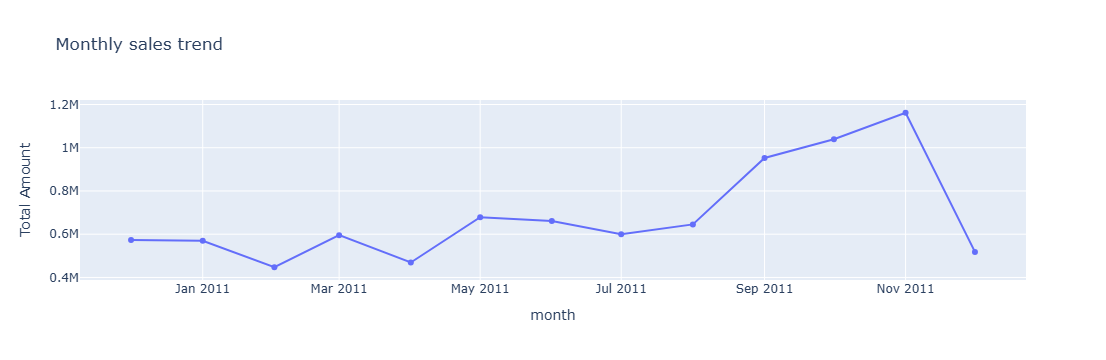

<Figure size 1000x600 with 0 Axes>

In [97]:
# VISUALIZE MONTHLY SALES USING PLOTY
plt.figure(figsize=(10,6))
fig=px.line(df_sort,x='month',y='Total Amount',title='Monthly sales trend',markers=True)
fig.show()

* Sales were relatively stable in first half but then after september there was a sudden increase and revenue picked around Nov, and was a sharp fall by December . this means sales are high mostly in festive or holiday season.

In [26]:
#Top 5 countries by revenue
top_country = df.groupby("Country")['Total Amount'].sum().sort_values(ascending=False)
country_count=top_country.head(5).reset_index()
country_count.columns=['Country','Total Amount']
country_count

,Country,Total Amount
0,United Kingdom,7308391.554
1,Netherlands,285446.340
2,EIRE,265545.900
3,Germany,228867.140
4,France,209024.050


In [27]:
#VISUALIIZE TOP Country BY TOTAL AMOUNT
fig=px.bar(country_count,x='Total Amount',y='Country',text='Total Amount',title="Top Countries by Total Amount")
fig.show()

* United Kingdom generated approximately 7.3 million in revenue.
The next best countries (Netherlands, EIRE, Germany, France) are far behind at around 200k–285k.
Insight: The business is highly dependent on the UK market and has limited international revenue diversification.

## RFM

In [28]:
#RECENCY
recency=df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency.columns=['CustomerID','InvoiceDate']
recent_date=recency['InvoiceDate'].max()
recency['Recent']=recency['InvoiceDate'].apply(lambda x:(recent_date-x).days)
recency.head()

,CustomerID,InvoiceDate,Recent
0,12346.0,2011-01-18 10:01:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309


In [29]:
#FREQUENCY
freq=df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
freq.columns=['CustomerID','Frequency']
freq.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [30]:
#MONETARY
monetary_df=df.groupby('CustomerID')['Total Amount'].sum().reset_index()
monetary_df.columns=['CustomerID','Monetary']
monetary_df.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [31]:
#merge recency,frequency and monetary
rf=recency.merge(freq,on='CustomerID')
rfm=rf.merge(monetary_df,on='CustomerID').drop(columns='InvoiceDate')
rfm.head()

,CustomerID,Recent,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


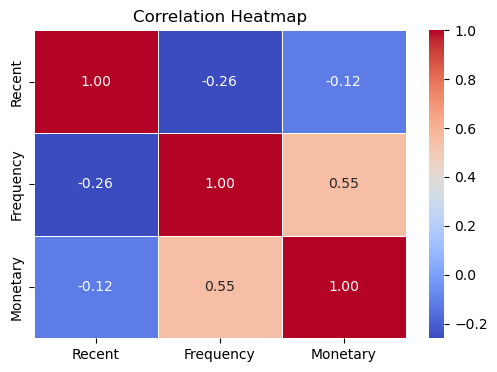

In [32]:
#VISUALIZING CORRELATION BTW RECENCY,FREQ,MONETARY
plt.figure(figsize=(6,4))
dataframe=pd.DataFrame(data=rfm,columns=['Recent','Frequency','Monetary'])
matrix=dataframe.corr()
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

* Frequency and Monetary have positive correlation(0.55),means customer who purchase frequently have generates revenue.
* Recency and frequency have weak negative correlation(-0.26),means customer who purchase recently tend to buy more frequently.
* Recency and Monetary have weak negative correlation(-.12) , means customeer who purchase recently spend slightly more.

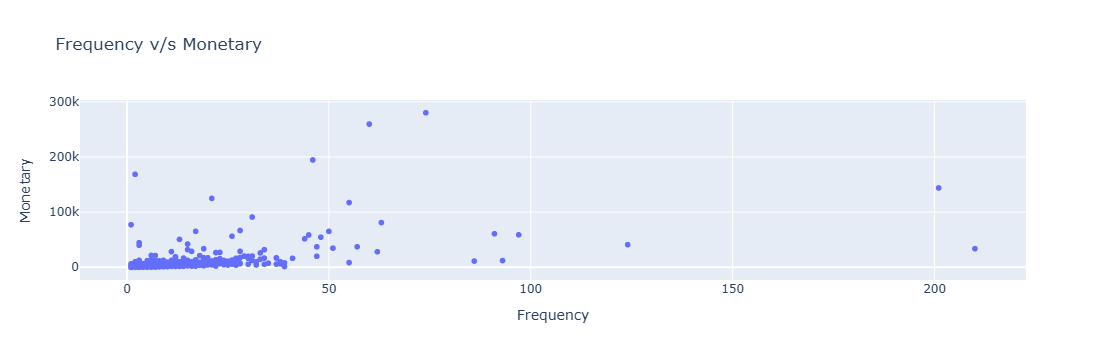

In [96]:
fig = px.scatter(rfm, x="Frequency", y="Monetary",hover_data=['CustomerID','Recent'],title='Frequency v/s Monetary')
fig.show()

## STANDARDSCALER

In [44]:
from sklearn import preprocessing
scaler=preprocessing.StandardScaler()
x = rfm[['Recent','Frequency','Monetary']]
standard_df=scaler.fit_transform(x)
standard_df=pd.DataFrame(standard_df,columns=['Recent','Frequency','Monetary'])
standard_df.head()

,Recent,Frequency,Monetary
0,2.334858,-0.424675,8.359634
1,-0.905199,0.354080,0.251046
2,-0.175186,-0.035297,-0.028546
3,-0.735196,-0.424675,-0.032963
4,2.174855,-0.424675,-0.191315


## K-Means Clustering

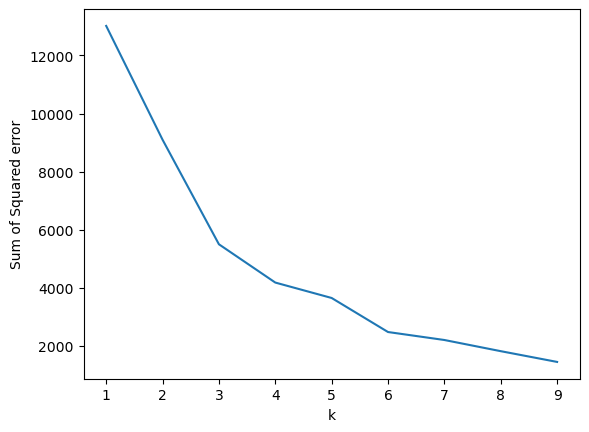

In [41]:
# ELBOW METHOD
sse=[] #sum of squared error
k_rng=range(1,10)  #k range
for k in k_rng:
    km=KMeans(n_clusters=k)
    km.fit(standard_df)
    sse.append(km.inertia_)  #inertia cal sse
plt.xlabel('k')
plt.ylabel("Sum of Squared error")
plt.plot(k_rng,sse)

* The Elbow Method was applied to determine the optimal number of clusters. The elbow plot showed a significant decrease in SSE (Sum of Squared Errors) up to K = 3, after which the decrease started slowing down. However, there was still a noticeable improvement at K = 4.
More importantly, K = 4 produced four distinct and meaningful customer segments.

In [55]:
km=KMeans(n_clusters=4)
y_predicted=km.fit_predict(standard_df)
rfm['cluster']=y_predicted
rfm.head(5)

,CustomerID,Recent,Frequency,Monetary,cluster
0,12346.0,325,1,77183.60,3
1,12347.0,1,7,4310.00,0
2,12348.0,74,4,1797.24,0
3,12349.0,18,1,1757.55,0
4,12350.0,309,1,334.40,1


In [49]:
km.cluster_centers_  #cluster center positions

array([[-0.8513522 , 10.17837486, 13.94030906],
       [-0.48826228, -0.07655054, -0.07735308],
       [ 1.55560357, -0.35302746, -0.17504599],
       [-0.77019691,  2.34423202,  1.18560648]])

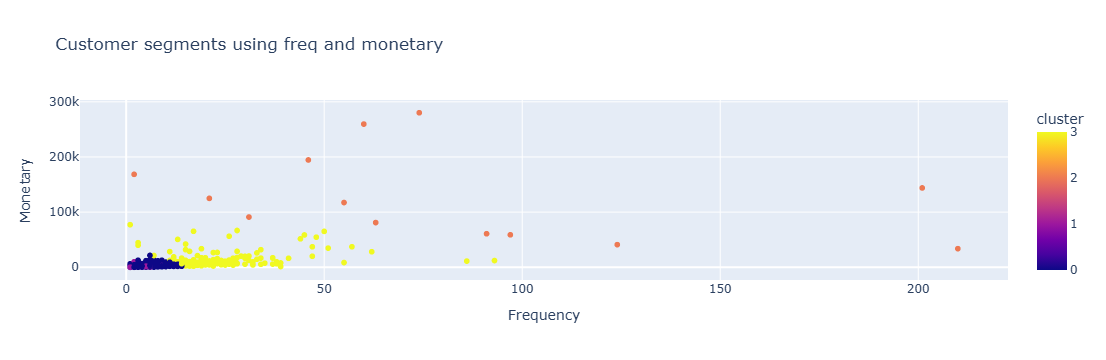

In [63]:
plot_df = standard_df.copy()
plot_df['cluster'] = rfm['cluster']
fig=px.scatter(rfm,x='Frequency',y='Monetary',color='cluster',title="Customer segments using freq and monetary")
fig.show()

* Most customers have low-moderate spending.
* A small amount of customer generate high revenue.
* Several high freq customer contribute disproportionately to sales.

In [64]:
#profile by cluster
rfm.groupby('cluster')[['Recent','Frequency','Monetary']].mean()

,Recent,Frequency,Monetary
cluster,,,
0,42.910580,3.655748,1349.698298
1,247.564030,1.551789,478.107581
2,6.384615,82.692308,127338.313846
3,14.672986,22.047393,12453.225924


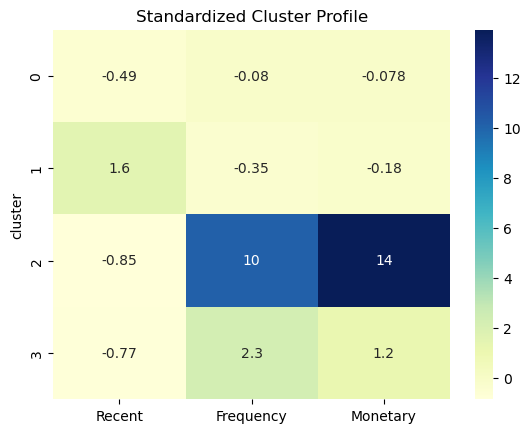

In [95]:
cluster_profile_scaled = (
    pd.DataFrame(
        standard_df,
        columns=['Recent','Frequency','Monetary']
    )
    .assign(cluster=rfm['cluster'])
    .groupby('cluster')
    .mean()
)
sns.heatmap(cluster_profile_scaled, annot=True, cmap='YlGnBu')
plt.title('Standardized Cluster Profile')
plt.show()

* The above table shows behaviour of 4 types of customers.
* Cluster 0- "REGULAR CUSTOMERS": Moderate recency,freq and monetary
* CLUSTER 1- "AT HIGH RISK": very high recency, low freq and low monetary
* Cluster 2- "VIP CUSTOMERS": very recent purchases, very frequent buyers and high monetary
* Cluster 3- "LOYAL CUSTOMER": recent purchases and freq good and monetary is also high

In [80]:
#NUMBER OF CLUSTER PER CLUSTER
country_cluster=rfm.groupby('cluster'
                          )['CustomerID'].count().reset_index()

country_cluster.columns=['Cluster','Customer']
country_cluster

,Cluster,Customer
0,0,3053
1,1,1062
2,2,13
3,3,211


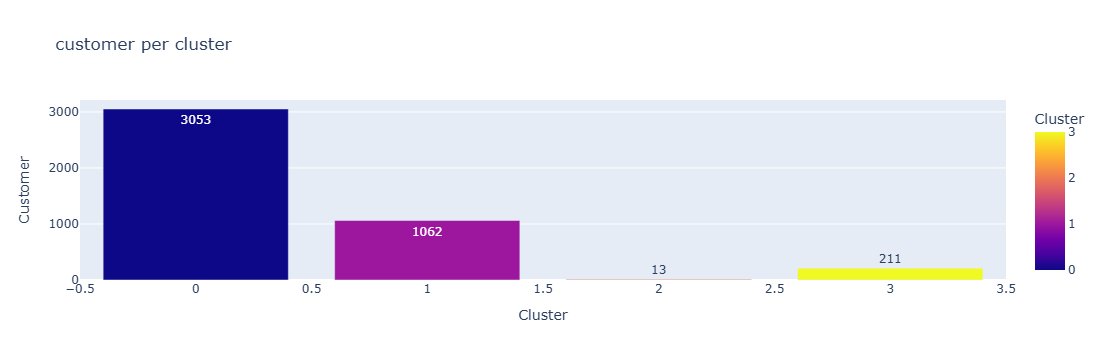

In [83]:
#visualization customer per cluster
fig=px.bar(country_cluster,x='Cluster',y='Customer',text='Customer',color='Cluster',title=" customer per cluster")
fig.show()

In [89]:
#Revenue/Monetary per cluster
amt_cluster=rfm.groupby('cluster')['Monetary'].sum().reset_index()
amt_cluster.columns=['Cluster','Monetary']
amt_cluster

,Cluster,Monetary
0,0,4120628.903
1,1,507750.251
2,2,1655398.080
3,3,2627630.670


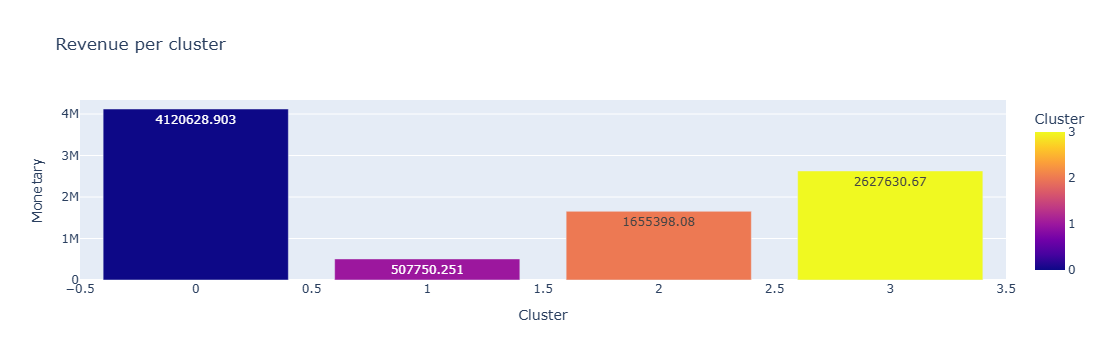

In [90]:
#visualization monetary per cluster
fig=px.bar(amt_cluster,x='Cluster',y='Monetary',text='Monetary',color='Cluster',title=" Revenue per cluster")
fig.show()

* CLUSTER 0 - Highest Revenue Contributor,generated 4.12 million revenue. These are regular customer although they dont spend much but there no. make them highest contriutor.
* CLUSTER 1- Lowest Revenue,generated 0.51 million only and low spending and low frequency. High risk of churn.
* CLUSTER 2- VIP customers,generates 1.66 million. Despite of being small segment they contribute more .
* CLUSTER 3- Second highest revenue .These are loyal customer.

# INSIGHT SECTION

-  Cluster 0 – Regular Customers
     - Personalized recommendations, Bundle offersSeasonal promotions, Increase purchase frequency through email campaigns

- Cluster 1 – At-Risk Customers
     - Win-back campaigns, Re-engagement emails, Discount vouchers, Limited-time offers

- Cluster 2 – VIP Customers
      - VIP membership program, Exclusive discounts, Early access to new products, Dedicated customer support

- Cluster 3 – Loyal Customers
       - Loyalty rewards program, Referral incentives, Cross-selling and upselling, Premium product recommendations